In [1]:
import sys

print(sys.executable)

C:\Users\gab\anaconda3\envs\bitcoin_ml\python.exe


In [2]:
import matplotlib
import ipympl
import ipywidgets

print("Matplotlib:", matplotlib.__version__)
print("ipympl:", ipympl.__version__)
print("ipywidgets:", ipywidgets.__version__)

Matplotlib: 3.11.0
ipympl: 0.10.0
ipywidgets: 8.1.8


In [3]:
%matplotlib widget

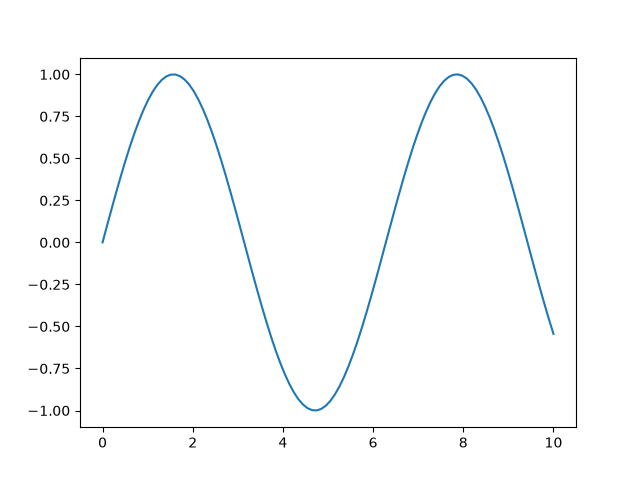

In [4]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)

plt.figure()
plt.plot(x, np.sin(x))
plt.show()

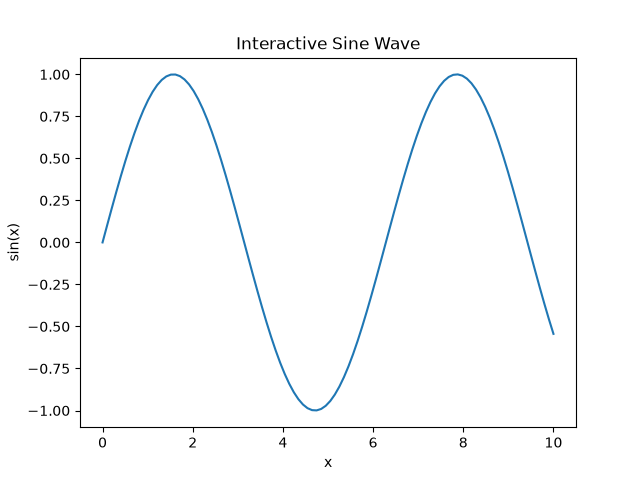

In [5]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots()

ax.plot(x, y)

ax.set_title("Interactive Sine Wave")
ax.set_xlabel("x")
ax.set_ylabel("sin(x)")

plt.show()

height=887,width=1774


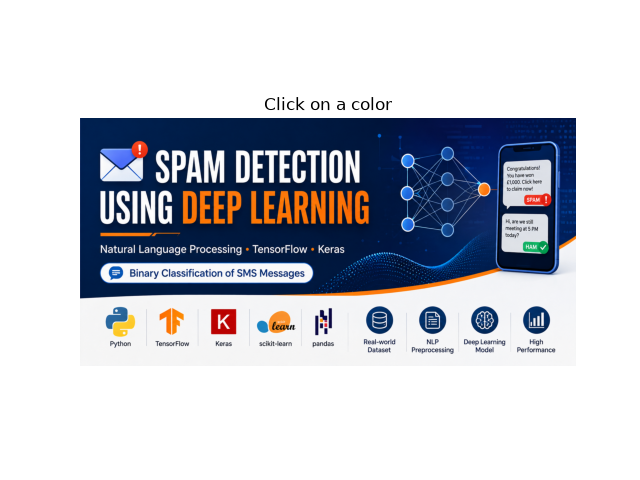

In [16]:
%matplotlib widget
import cv2
import numpy as np
import matplotlib.pyplot as plt
img=cv2.imread('banner.png.png')
img
h,w=img.shape[:2]
print("height={},width={}".format(h,w))
# Load image
image = img

# Check image
if image is None:
    print("Image could not be loaded")
else:

    # Convert BGR to RGB for Matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Convert BGR to HSV for OpenCV processing
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Store clicked HSV values
    points = []

    # Create figure
    fig, ax = plt.subplots()

    # Display image
    ax.imshow(image_rgb)
    ax.set_title("Click on a color")
    ax.axis("off")

    # Mouse click function
    def onclick(event):

        # Make sure click happened inside image
        if event.xdata is not None and event.ydata is not None:

            # Matplotlib gives x,y coordinates
            x = int(event.xdata)
            y = int(event.ydata)

            # Get BGR and HSV values
            bgr_value = image[y, x]
            hsv_value = hsv[y, x]

            # Store HSV
            points.append(hsv_value)

            print("Position:", (x, y))
            print("BGR:", bgr_value)
            print("HSV:", hsv_value)
            print("Collected:", len(points))
            print("------------------------")

    # Connect mouse click to function
    cid = fig.canvas.mpl_connect(
        "button_press_event",
        onclick
    )

    plt.show()

In [17]:
points = np.array(points)

print("Minimum HSV:", points.min(axis=0))
print("Maximum HSV:", points.max(axis=0))

Minimum HSV: [  5 210 244]
Maximum HSV: [ 15 255 254]


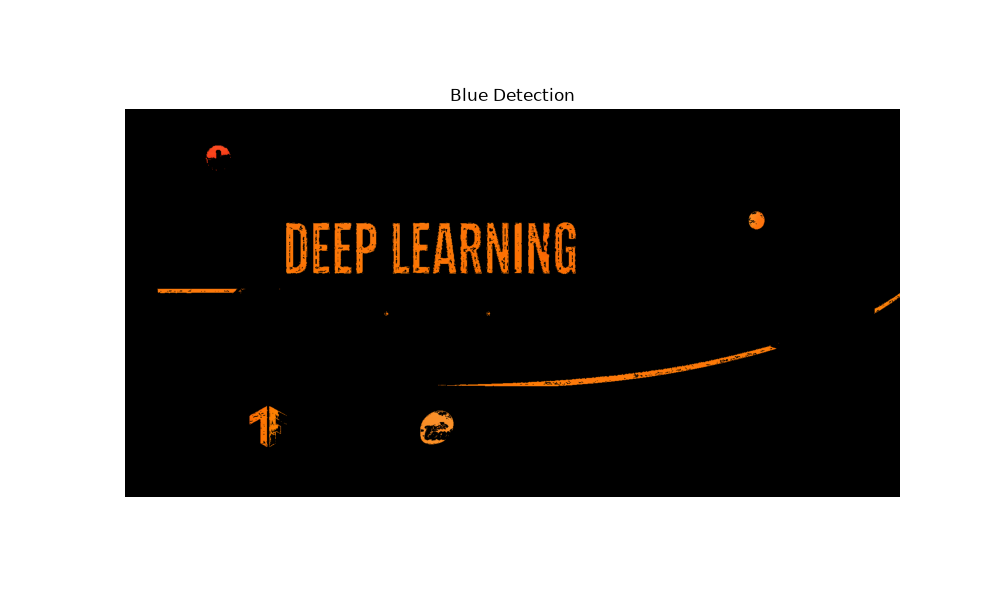

In [18]:
mask = cv2.inRange(hsv,  points.min(axis=0), points.max(axis=0))
result = cv2.bitwise_and(img, img, mask=mask)
plt.figure(figsize=(10, 6))

plt.imshow(
    cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
)

plt.title("Blue Detection")
plt.axis("off")

plt.show()


In [19]:
contours, hierarchy = cv2.findContours(
    mask,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

print("Number of contours:", len(contours))

Number of contours: 124


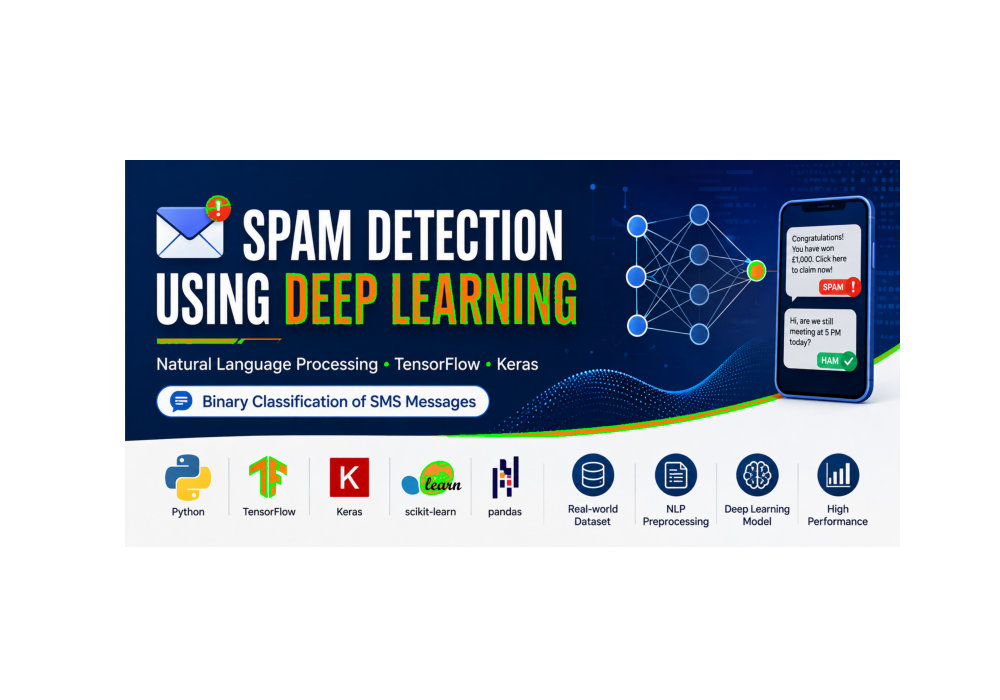

In [20]:
contour_image = img.copy()

cv2.drawContours(
    contour_image,
    contours,
    -1,
    (0, 255, 0),
    2
)

plt.figure(figsize=(10, 7))

plt.imshow(
    cv2.cvtColor(contour_image, cv2.COLOR_BGR2RGB)
)

plt.axis("off")
plt.show()